## Regresión lineal
Busca los parámetros que minimizen la función de perdida.

In [ ]:
from sklearn.linear_model import LinearRegression # regresión lineal
from sklearn.metrics import mean_squared_error, r2_score #métricas para el modelo de regresión

# 1. Instanciar y entrenar
model = LinearRegression() #instancia
model.fit(X_train, y_train) #entreno (suponiendo que ya se particionaron los datos)

# 2. Predecir y evaluar
y_pred = model.predict(X_test) #predecir

#Métricas
print(f'RMSE: {mean_squared_error(y_test, y_pred, squared=False):.2f}') 
print(f'R²:   {r2_score(y_test, y_pred):.3f}')

# 3. Inspeccionar coeficientes
print('Intercepto:', model.intercept_)
print('Coeficientes:', dict(zip(feature_names, model.coef_))

# En caso de necesitar un modelo polinómico entonces se usa la función PolynomialFeatures de scikit learn

Supongamos una regresión con 2 varibles, por tanto se usan dos parámetros $\betha_1$ y $\betha_2$ por tanto la función de perdida es una fucnión en $R^3$ que por la ecuación de mínimos cuadrados ordinarios es un paraboloide elíptico que el punto más bajo es la coordenada donde se minimizan $\betha_1$ y $\betha_2$. 

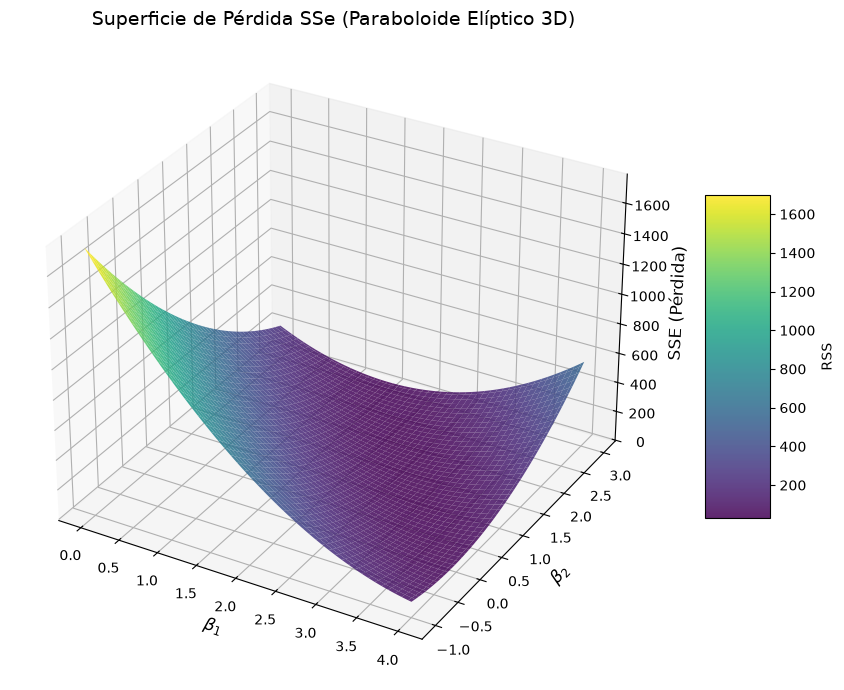

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generar datos sintéticos (n = 100)
np.random.seed(42)
X1 = np.random.randn(100)
X2 = 0.8 * X1 + 0.3 * np.random.randn(100) # X1 y X2 altamente correlacionadas
y = 2.5 * X1 + 1.5 * X2 + np.random.randn(100) * 0.5

# 2. Grilla de parámetros (beta_1 y beta_2)
beta1_range = np.linspace(0, 4, 100)
beta2_range = np.linspace(-1, 3, 100)
B1, B2 = np.meshgrid(beta1_range, beta2_range)

# 3. Calcular la suma de cuadrados de los residuos para cada combinación de (beta_1, beta_2)
SSE = np.zeros(B1.shape)
for i in range(B1.shape[0]):
    for j in range(B1.shape[1]):
        #crear a Y_ajustado
        y_pred = B1[i, j] * X1 + B2[i, j] * X2
        #calcular suma de cuadrados de los residuos
        SSE[i, j] = np.sum((y - y_pred)**2)

# 4. Graficar el Paraboloide Elíptico en 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# B1 puntos eje X, B2 para eje Y, y SSE  para eje Z
surf = ax.plot_surface(B1, B2, SSE, cmap='viridis', alpha=0.85, edgecolor='none')
ax.set_xlabel(r'$\beta_1$', fontsize=12)
ax.set_ylabel(r'$\beta_2$', fontsize=12)
ax.set_zlabel('SSE (Pérdida)', fontsize=12)
ax.set_title('Superficie de Pérdida SSe (Paraboloide Elíptico 3D)', fontsize=14)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='RSS')

plt.tight_layout()
plt.show()

In [4]:
SSE.shape

(100, 100)

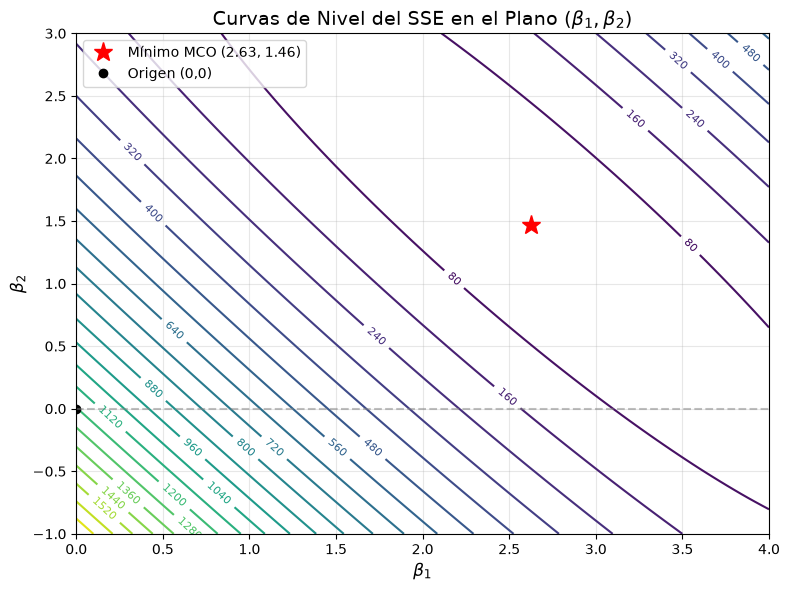

In [5]:
# para ver las curvas de nivel
# 5. Encontrar el mínimo numérico (OLS) en la grilla para marcarlo
# np.argmin() retorna le índice del valor más pequeño
# np.unravel_index es para que den las coordenadas reales
# por si hay filas vacias. 
min_idx = np.unravel_index(np.argmin(SSE), SSE.shape)
b1_ols = B1[min_idx]# mínimo en B1
b2_ols = B2[min_idx]# mínimo en B2

# 6. Graficar Curvas de Nivel en 2D
plt.figure(figsize=(8, 6))
#plt.controur es para gráficar curvas de nivel. 
contours = plt.contour(B1, B2, SSE, levels=25, cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8, fmt='%1.0f')

# Marcar el punto mínimo OLS
plt.plot(b1_ols, b2_ols, 'r*', markersize=14, label=f'Mínimo MCO ({b1_ols:.2f}, {b2_ols:.2f})')
plt.plot(0, 0, 'k o', markersize=6, label='Origen (0,0)')

plt.xlabel(r'$\beta_1$', fontsize=12)
plt.ylabel(r'$\beta_2$', fontsize=12)
plt.title('Curvas de Nivel del SSE en el Plano ' + r'$(\beta_1, \beta_2)$', fontsize=14)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Regresión ridge y lasso

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso #ridge y lasso
from sklearn.preprocessing import StandardScaler

# 1. SIEMPRE estandarizar primero para Ridge y Lasso
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Entrenar los tres modelos
rl = LinearRegression().fit(X_scaled, y) #regresión lineal 
ridge = Ridge(alpha=1.0).fit(X_scaled, y)  # alpha es equivalente a lambda
lasso = Lasso(alpha=1.0).fit(X_scaled, y)

# 3. Inspeccionar coeficientes
print("rl:", ols.coef_)
print("Ridge:", ridge.coef_)
print("Lasso:", lasso.coef_)

Ejemplo real y comparación de las regresiones

=== MÉTRICAS EN CONJUNTO DE TEST ===
      Modelo  MSE (Test)  R2 (Test)
MCO (Normal)     2900.19      0.453
  Ridge (L2)     2867.95      0.459
  Lasso (L1)     2799.10      0.472


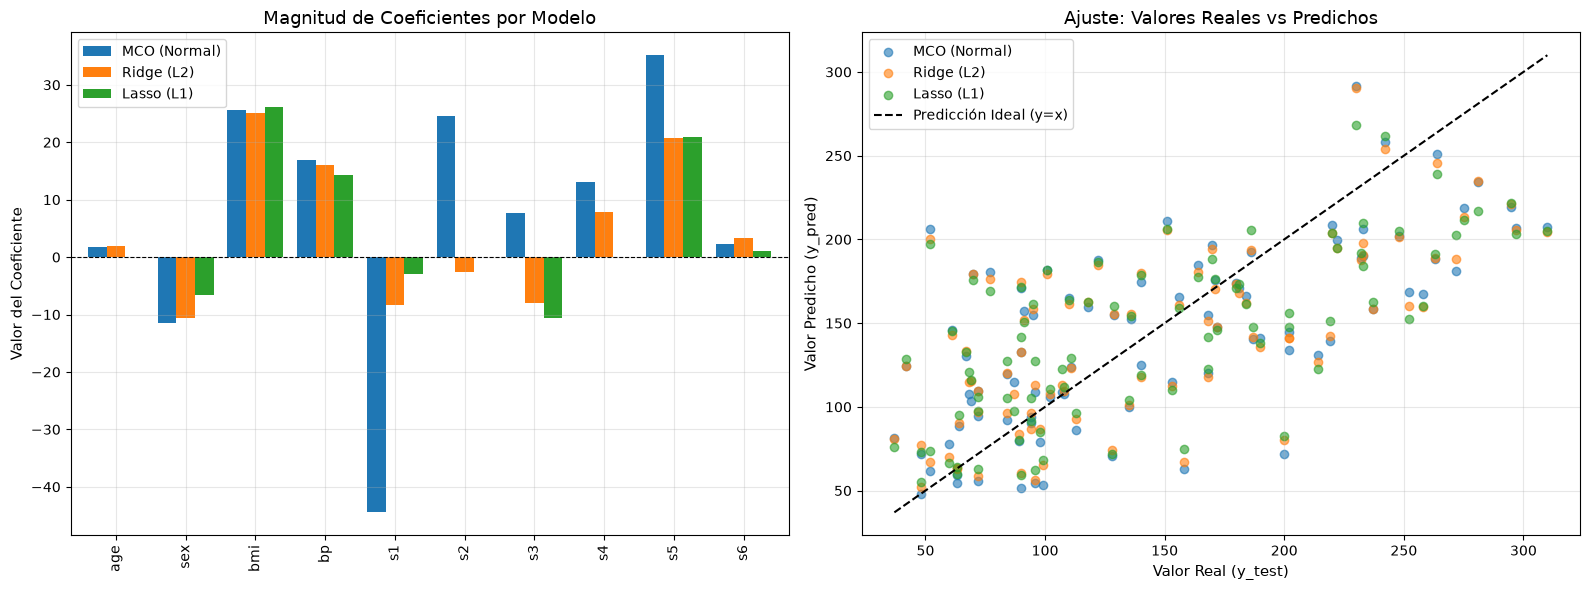

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_diabetes # datos
from sklearn.model_selection import train_test_split #partición de datos
from sklearn.preprocessing import StandardScaler  #estandarización
from sklearn.linear_model import LinearRegression, Ridge, Lasso #regresiones
from sklearn.metrics import mean_squared_error, r2_score #métricas

# 1. Cargar conjunto de datos real
diabetes = load_diabetes()
#volver los datos un data frame
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target #varible respuesta

# Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. ESTANDARIZACIÓN (Paso crítico para Ridge y Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Definir y entrenar modelos
models = {
    'MCO (Normal)': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=20.0),
    'Lasso (L1)': Lasso(alpha=2.5)
}

results = []
coefs_dict = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({'Modelo': name, 'MSE (Test)': round(mse, 2), 'R2 (Test)': round(r2, 3)})
    coefs_dict[name] = model.coef_

# 4. Mostrar métricas comparativas
df_results = pd.DataFrame(results)
print("=== MÉTRICAS EN CONJUNTO DE TEST ===")
print(df_results.to_string(index=False))

# 5. Gráficos Comparativos (Coeficientes y Ajuste)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Comparación de Coeficientes
df_coefs = pd.DataFrame(coefs_dict, index=diabetes.feature_names)
df_coefs.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('Magnitud de Coeficientes por Modelo', fontsize=13)
axes[0].set_ylabel('Valor del Coeficiente', fontsize=11)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].grid(True, alpha=0.3)

# Gráfico B: Valores Reales vs Predichos
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    axes[1].scatter(y_test, y_pred, alpha=0.6, label=name)

# Línea ideal de predicción
min_val = min(y_test.min(), min(y_pred))
max_val = max(y_test.max(), max(y_pred))
axes[1].plot([min_val, max_val], [min_val, max_val], 'k--', label='Predicción Ideal (y=x)')

axes[1].set_title('Ajuste: Valores Reales vs Predichos', fontsize=13)
axes[1].set_xlabel('Valor Real (y_test)', fontsize=11)
axes[1].set_ylabel('Valor Predicho (y_pred)', fontsize=11)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## ElasticNet

In [ ]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

# 1. Cargar y dividir los datos
X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Estandarizar variables (Mandatorio)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Definir la rejilla de búsqueda para alpha y l1_ratio
param_grid = {
    'alpha': np.logspace(-3, 2, 10),       # Valores de 0.001 a 100
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]  # Balance entre L1 (Lasso) y L2 (Ridge)
}

# 4. Entrenar ElasticNet con Validación Cruzada (5-Fold)
elastic = ElasticNet(max_iter=10000, random_state=42)
grid_search = GridSearchCV(elastic, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train_scaled, y_train)

# 5. Evaluar el mejor modelo en el conjunto de prueba
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

print(f"Mejor Alpha: {grid_search.best_params_['alpha']:.4f}")
print(f"Mejor L1 Ratio: {grid_search.best_params_['l1_ratio']}")
print(f"MSE en Test: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R2 Score en Test: {r2_score(y_test, y_pred):.3f}")
print("Coeficientes finales:", np.round(best_model.coef_, 2))

| Escenario / Estructura de Datos | MCO (Clásica) | Ridge (L2) | Lasso (L1) | ElasticNet (L1 + L2) |
| :--- | :---: | :---: | :---: | :---: |
| **Pocas variables y sin multicolinealidad ($p \ll n$)** | **Ideal** | Innecesario | Innecesario | Innecesario |
| **Alta Multicolinealidad (Variables correlacionadas)** | Falla | **Excelente** | Regular *(Elige 1 al azar)* | **Excelente** *(Efecto agrupadador)* |
| **Muchas variables irrelevantes / Ruido ($p$ grande)** | Sobreajusta | Regular *(Solo las encoge)* | **Excelente** *(Hace $\beta=0$)* | **Excelente** |
| **Más variables que observaciones ($p > n$)** | No calcula | Funciona | Máximo $n$ variables | **Ideal** *(Sin límite de $n$)* |
| **Selección de características / Interpretabilidad** | No | No | **Sí** | **Sí** |
| **Modelo base recomendado si hay duda** | No | No | No | **Recomendado** |

## árbol de decisión
predecir una variable continua (el precio de casas basado en su tamaño) mediante un Árbol de Decisión de Regresión

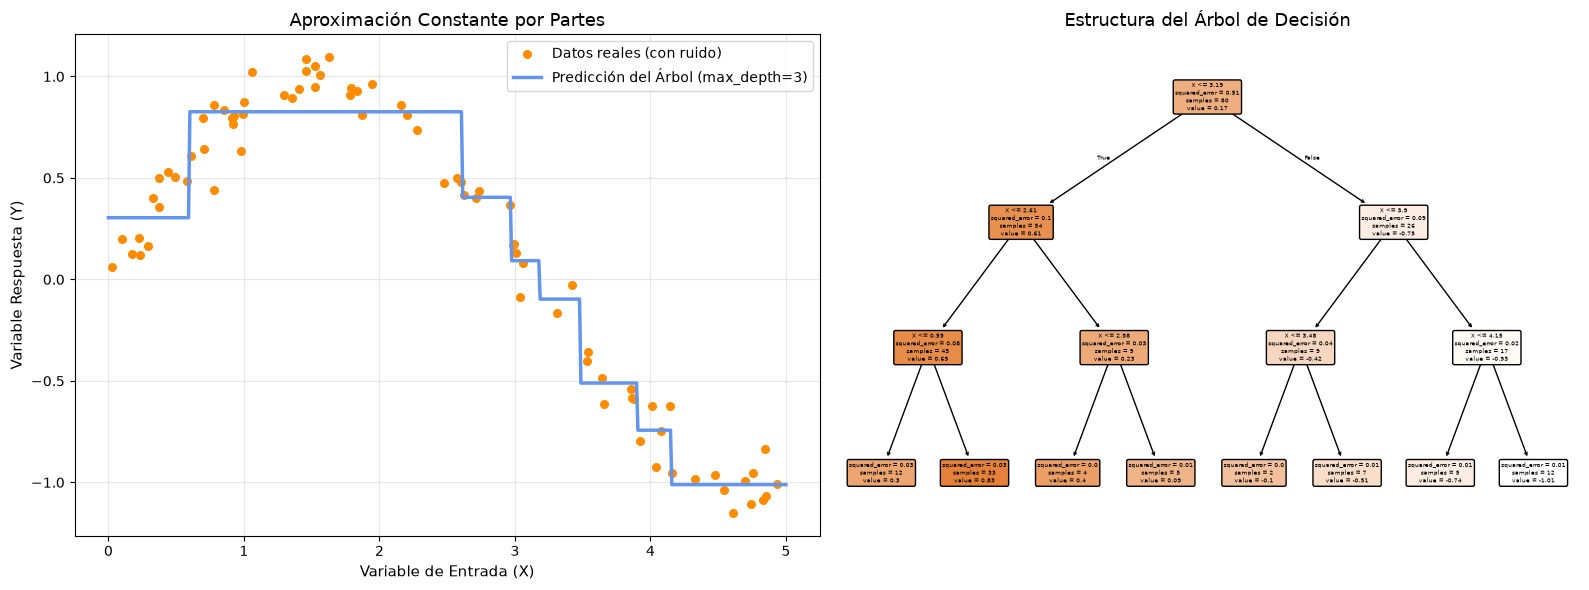

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree # árbol de decisión y gráfico

# 1. Generar datos sintéticos no lineales (Metros cuadrados vs Precio)
np.random.seed(42)
X = np.sort(5 * np.random.rand(80, 1), axis=0) # Variable X: Tamaño ordenada
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0]) # Variable Y: Precio (relación no lineal) 
#es una relación sinusoidal con un ruido.  .ravel() convierte el arreglo en una dimension una matriz a un solo 
#vector largo. 

# 2. Crear y entrenar el modelo de Árbol de Regresión
# max_depth controla la profundidad para evitar el sobreajuste (overfitting)
tree_reg = DecisionTreeRegressor(max_depth=3, random_state=42) #instancia con criterio de parada
#recordemos que el criterio de parada es el número de pasos permitido hasta la hoja más lejana.
tree_reg.fit(X, y) #ajuste

# 3. Predecir sobre un rango continuo para ver la función aprendida
X_test = np.linspace(0, 5, 500)[:, np.newaxis]
y_pred = tree_reg.predict(X_test) #predicciónes

# 4. Graficar los resultados y el árbol resultante
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Datos reales vs Predicción escalonada (Por partes)
axes[0].scatter(X, y, color='darkorange', label='Datos reales (con ruido)', s=30)
axes[0].plot(X_test, y_pred, color='cornflowerblue', label='Predicción del Árbol (max_depth=3)', linewidth=2.5)
axes[0].set_xlabel('Variable de Entrada (X)', fontsize=11)
axes[0].set_ylabel('Variable Respuesta (Y)', fontsize=11)
axes[0].set_title('Aproximación Constante por Partes', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico B: Estructura del Árbol de Decisión
plot_tree(tree_reg, feature_names=['X'], filled=True, ax=axes[1], rounded=True, precision=2)
axes[1].set_title('Estructura del Árbol de Decisión', fontsize=13)

plt.tight_layout()
plt.show()

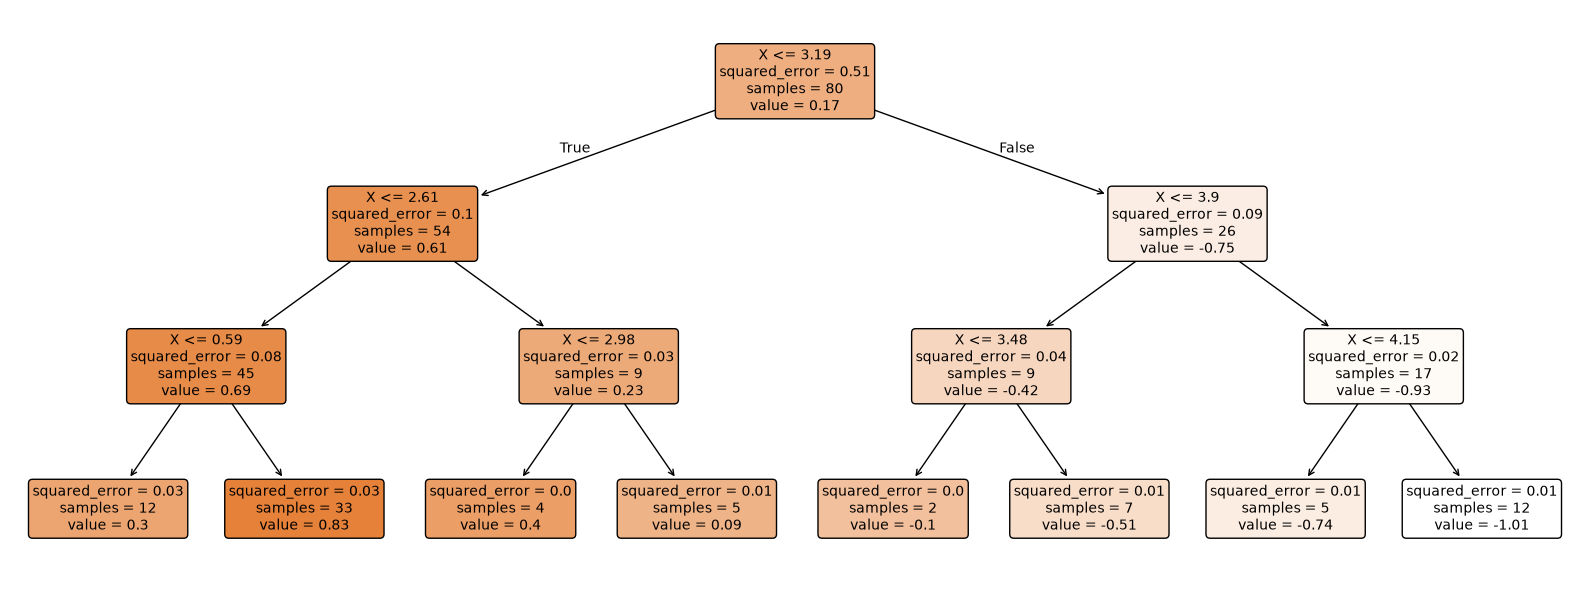

In [4]:
# 3. Predecir sobre un rango continuo para ver la función aprendida
X_test = np.linspace(0, 5, 500)[:, np.newaxis]
y_pred = tree_reg.predict(X_test) #predicciónes

# 4. Graficar los resultados y el árbol resultante
fig, axes = plt.subplots( figsize=(16, 6))

# Gráfico B: Estructura del Árbol de Decisión
plot_tree(tree_reg, feature_names=['X'], filled=True, ax=axes, rounded=True, precision=2)
plt.tight_layout()
plt.show()

In [ ]:
tree_reg.predict([[3]]) # el valor de la decisión viene dado por los nodos hoja. 

array([0.09240391])

## Bosque aleatorio

In [1]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Cargar datos
X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Entrenar Random Forest Regressor
# n_estimators: número de árboles | max_features: m variables por corte
rf = RandomForestRegressor(
    n_estimators=100, #número de árboles
    max_features="sqrt", #número de variables, la raíz del número de varibles
    random_state=42, 
    n_jobs=-1 # usar todos los núcleos disponibles
)
rf.fit(X_train, y_train)

# 3. Predicción y Evaluación
y_pred = rf.predict(X_test)

print(f"MSE en Test: {mean_squared_error(y_test, y_pred):.4f}")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")

MSE en Test: 0.2489
R² Score: 0.8101


In [2]:
# para calcular el error out of box
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error

# 1. Cargar datos
X, y = fetch_california_housing(return_X_y=True)

# 2. Entrenar Random Forest activando oob_score
rf = RandomForestRegressor(
    n_estimators=100, 
    oob_score=True,       # Habilita la estimación OOB
    random_state=42, 
    n_jobs=-1
)
rf.fit(X, y)

# 3. Extraer la métrica OOB (por defecto en scikit-learn devuelve R^2)
print(f"OOB R² Score: {rf.oob_score_:.4f}")

# 4. Convertir a MSE OOB (usando la predicción OOB que guarda internamente)
oob_mse = mean_squared_error(y, rf.oob_prediction_)
print(f"OOB MSE: {oob_mse:.4f}")

OOB R² Score: 0.8120
OOB MSE: 0.2503
